## 1D diffusion equation
Solution of the 1D diffusion equation using:
1. Explicit method
2. Implicit method
    - ~Thomas Algorithm~
    - Iterative methods (Jacobi, Gauss-Seidel)

## 1D Diffusion Equation
$$ \frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2} $$


### Finite Difference Method in Space

### First Derivative In Space

#### Forward Difference Method

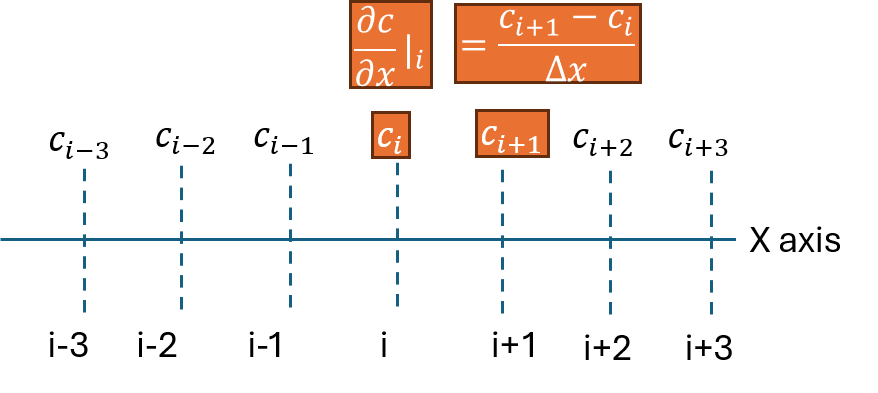

Taylor Series Expansion of concentration $c$ at the next grid point $x_{i+1} = x_i + \Delta x$ around point $x_i$:
$$c_{i+1} = c_i + \Delta x \left.\frac{\partial c}{\partial x}\right\vert{}_i + \frac{\Delta x^2}{2!} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i + \dots$$ 

Isolate the derivative term: 
$$\frac{c_{i+1} - c_i}{\Delta x} = \left.\frac{\partial c}{\partial x}\right\vert{}_i + \frac{\Delta x}{2} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i \dots$$

##### Find the Truncation Error

Rearranging to get $\left.\frac{\partial c}{\partial x}\right\vert{}_i$:$$\left.\frac{\partial c}{\partial x}\right\vert{}_i = \underbrace{\frac{c_{i+1} - c_i}{\Delta x}}_{\text{Forward Difference}} - \underbrace{\left[ \frac{\Delta x}{2} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i + \dots \right]}_{\text{Truncation Error}}$$

$\implies$ Error is $O(\Delta x)^1 \implies$ as $\Delta x$ halves error also halves.   

#### Backward Difference Method

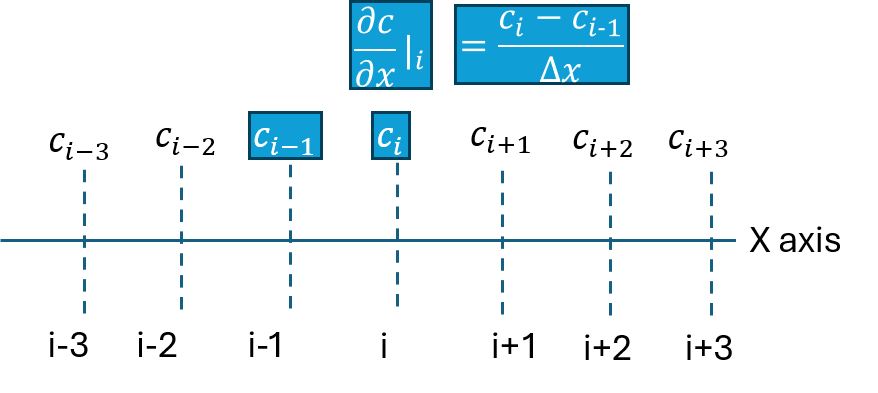

Taylor Series Expansion of concentration $c$ at the previous grid point $x_{i-1} = x_i - \Delta x$ around point $x_i$:
$$c_{i-1} = c_i - \Delta x \left.\frac{\partial c}{\partial x}\right\vert{}_i + \frac{\Delta x^2}{2!} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i + \dots$$ 

Isolate the derivative term: 
$$\frac{c_{i} - c_{i-1}}{\Delta x} = \left.\frac{\partial c}{\partial x}\right\vert{}_i - \frac{\Delta x}{2} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i \dots$$

##### Find the Truncation Error

Rearranging $\left.\frac{\partial c}{\partial x}\right\vert{}_i$: 
$$\left.\frac{\partial c}{\partial x}\right\vert{}_i = \underbrace{\frac{c_{i} - c_{i-1}}{\Delta x}}_{\text{Backward Difference}} + \underbrace{\left[ \frac{\Delta x}{2} \left.\frac{\partial^2 c}{\partial x^2}\right\vert{}_i + \dots \right]}_{\text{Truncation Error}}$$

$\implies$ Error is $O(\Delta x)^1 \implies$ as $\Delta x$ halves error also halves.   

#### Central Difference:
$$\left. \frac{\partial c}{\partial x} \right\vert{}_i \approx \frac{c_{i+1} - c_{i-1}}{2\Delta x}$$ 
Error: Second-order ($O(\Delta x^2)$). 

**Derive this order of error term as ungraded homework**

### Second Derivative In Space

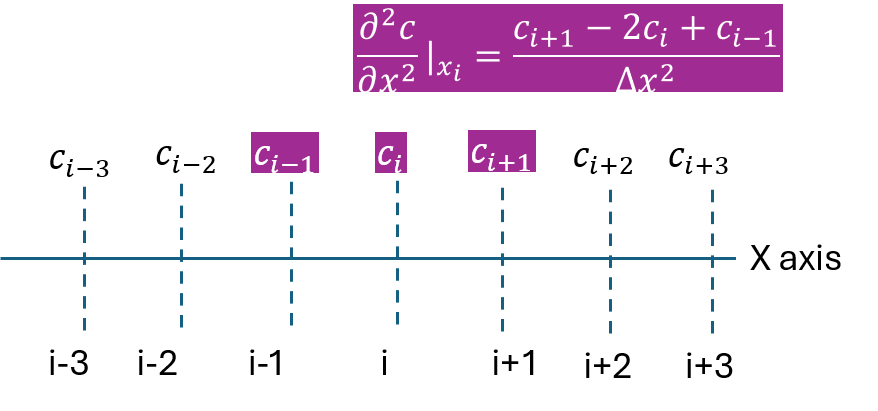

Taylor series expansion of concentration $c$ at neighboring points $x_{i+1}$ and $x_{i-1}$ around the point $x_i$:

At ($x_{i+1}$):

$$c_{i+1} = c_i + \Delta x \frac{\partial c}{\partial x} + \frac{\Delta x^2}{2!} \frac{\partial^2 c}{\partial x^2} + \frac{\Delta x^3}{3!} \frac{\partial^3 c}{\partial x^3} + \dots $$

At ($x_{i-1}$):$$c_{i-1} = c_i - \Delta x \frac{\partial c}{\partial x} + \frac{\Delta x^2}{2!} \frac{\partial^2 c}{\partial x^2} - \frac{\Delta x^3}{3!} \frac{\partial^3 c}{\partial x^3} + \dots$$2.

Add above 2 eqns. $\frac{\partial c}{\partial x}$ cancels out: 

$$c_{i+1} + c_{i-1} = 2c_i + \Delta x^2 \frac{\partial^2 c}{\partial x^2} + \mathcal{O}(\Delta x^4)$$3. 
Rearranging for the second derivative gives the central difference formula: 
$$\frac{\partial^2 c}{\partial x^2} \vert_{x_i} = \frac{c_{i+1} - 2c_i + c_{i-1}}{\Delta x^2} + O(\Delta x^2) \approx \frac{c_{i+1} - 2c_i + c_{i-1}}{\Delta x^2}$$

## FTCS (Forward-Time Central-Space) scheme: Type of Explicit method 
$$\frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2}$$

It discretizes **time** using a **first-order forward difference** and **space** using a **second-order central difference**:
$$\frac{c_i^{t+1} - c_i^t}{\Delta t} = D \frac{c_{i+1}^t - 2c_i^t + c_{i-1}^t}{\Delta x^2}$$

Rearranging to solve for the concentration at the next time step ($c_i^{t+1}$) gives the **explicit** update formula:

$$c_i^{t+1} = c_i^t + D \frac{\Delta t}{\Delta x^2} \left( c_{i+1}^t - 2c_i^t + c_{i-1}^t \right)$$

Error: First-order in time, $O(\Delta t)$, and second-order in space, $O(\Delta x^2)$.

## Types of Boundary Conditions (BCs)
Since we are solving $c(x,t)$, which is a function of both time and space, both spatial and temporal (time) boundary conditions are required. 
The number of minimum boundary conditions required are dependent upon the order of derivative.

In our case of 1D diffusion equation,
1. First order derivative in time, then one initial value is required. 
2. 2nd order derivative in space, minimum of 2 BCs are required, usually specified at the end points of the spatial domain.

## Temporal boundary condition (Initial Value) 
The time boundary condition is also called as the **initial value** (similar to initial value problem done previously). Here, the $c(x,t=0)$ should be specified at **all x**, for **t = 0**.

### Spatial Boundary Condition
$$ \frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2} $$
Let's have our discretized grid with N_x points, {0, 1, 2, ... N_x-2, N_x-1}.

For $ i \in [1, N\_x-2]$, 
$$ \frac{c^{t+1}_i - c^t_i}{\Delta t} = D \frac{ c^t_{i+1} - 2c^t_{i} + c^t_{i-1} }{{\Delta x}^2} = dc\_dt $$
$$ c^{t+1}_i =  c^t_i + \Delta t \; (dc\_dt) $$

This is $N\_x - 2$ equations, but we have $N\_x$ unknowns. Hence, we need `2` more conditions, called as spatial **boundary conditions**.  

For $ i == 0 $ and $ i == N\_x -1 $, we must know the value of $c_i$ **at all t** from the boundary conditions.


### Spatial boundary condition Types
#### These are spatial boundary conditions and need to applied at each timestep.
These are the 3 types of boundary conditions:

### Dirichlet Boundary Condition
Exact value of the concentration at the boundary points (i.e., $c_0$ and $c_{N_x-1}$) is **fixed** or **known** for **all times $t$**. 

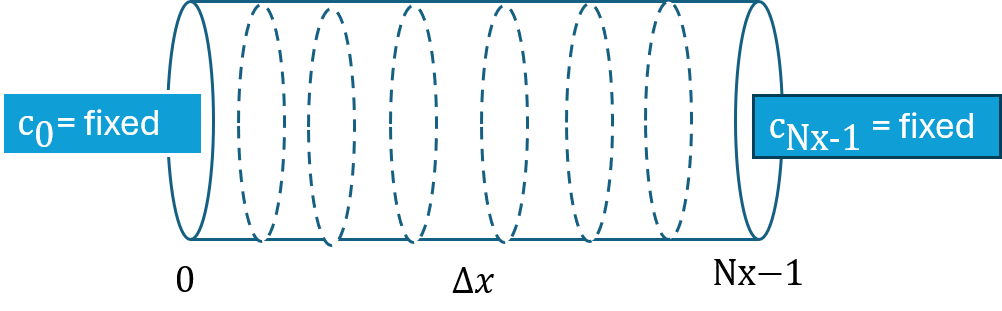

### Neumann Boundary condition

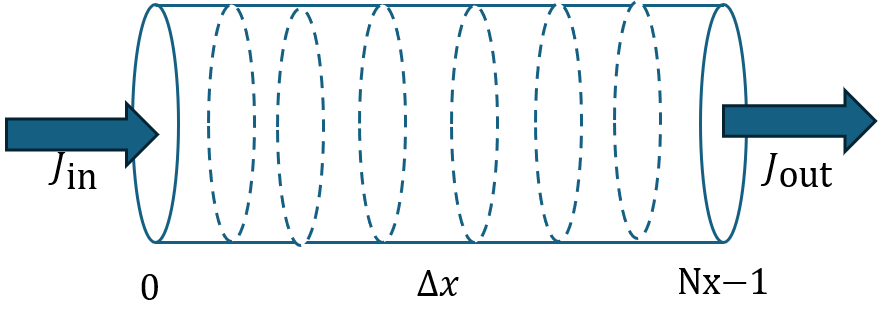

### Neumann Boundary condition
Fluxes (J) (i.e. concentration gradient) at the end points (i.e. $x = 0$ and $x = N_x−1$) are **known** at **all time t**.
1. Flux $J_{x=0} = -D\frac{\partial c}{\partial x}|_{x=0}$ = known at all times
1. Flux $J_{x=N_x-1} = -D\frac{\partial c}{\partial x}|_{x=N_x-1}$ = known at all times

Neumann boundary condition controls the specific rate of material/concentration flow. In most cases, we take J = 0, means no material enters or leaves the system.


#### Simplification for zero flux condition
##### Left boundary
1. For a zero-flux condition at the left boundary ($x=0$), the physical requirement is:
$$\left. \frac{\partial c}{\partial x} \right|_{x=0} = 0$$

Using a first-order forward difference at the first grid point ($i=0$):
$$\frac{c_1 - c_0}{\Delta x} = 0 \implies c_0 = c_1$$

##### Right boundary
2. For the right boundary ($i = N_x-1$), using a backward difference:
$$\frac{c_{N_x-1} - c_{N_x-2}}{\Delta x} = 0 \implies c_{N_x-1} = c_{N_x-2}$$

### Periodic boundary condition
A periodic boundary condition treats the system as if it is infinite and repeating. When a particle or an atom exits one side of the simulation domain, it enters from the opposite side. In our case of 1D diffusion equation it becomes:
1. The first point's neighbor to the left is the last point: $c_{-1} = c_{N_x-1}$
1. The last point's neighbor to the right is the first point: $c_{N_x} = c_{0}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_x = 20
timesteps = 1000
dx = 1.0
dt = 0.2
Diffusivity = 1.0

In [3]:
x_array = np.arange(0, N_x, dx)

In [14]:
def apply_BC(c):
    # Dirichlet (fixed) boundary condition
    c[0] = 1.0
    c[N_x-1] = 0.0
    # Neumann (zero flux) boundary condition
    # c[0] = c[1] # not the reverse
    # c[N_x-1] = c[N_x-2] # not the reverse
    return

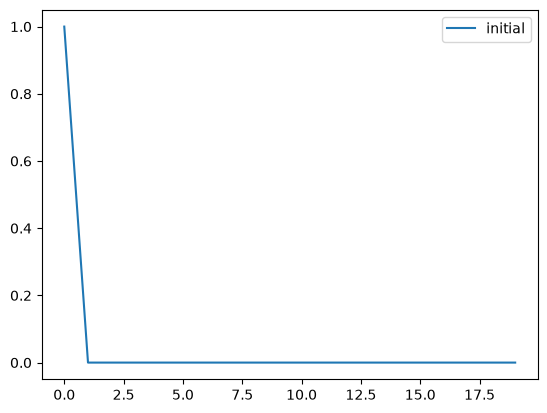

In [15]:
c_exp = np.zeros(N_x)
c_exp_new = np.zeros(N_x)
# c_exp[N_x//2] = 1.0 # initialization
c_exp[0] = 1.0
c_exp[N_x-1] = 0.0
# apply_BC(c_exp)

# plotting initial profile
plt.plot(x_array, c_exp, label='initial')
plt.legend()
plt.show()

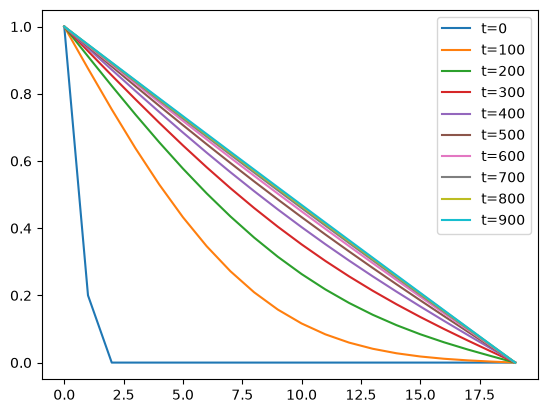

In [16]:
# explicit solution
for t in range(timesteps):
    for i in range(1, N_x-1): # exclude the first and last point
        dc_dt = Diffusivity*( c_exp[i-1] - 2*c_exp[i] + c_exp[i+1] )/(dx**2)
        c_exp_new[i] = c_exp[i] + dc_dt*dt
    apply_BC(c_exp_new) # apply boundary condition at each time step
    c_exp = np.copy(c_exp_new) # copying updated values to c_exp
    if t%100 == 0: 
        plt.plot(x_array, c_exp, label='t=' + str(t))
plt.legend()
plt.show()

## Von Neumann Stability Analysis

For a stable solution using the FTCS explicit method: $\alpha = \frac{D \Delta t}{(\Delta x)^2} \leq 0.5$.

This means for a fixed $\Delta x$, the $\Delta t$ has an upper limit. This is what we also saw in the first lecture 1D IVP scheme 

## Implicit expression:
### Backward Time Centred Space (BTCS):
$$ \frac{\partial c}{\partial t} = D \frac{\partial^2 c}{\partial x^2} $$

$$ \frac{c^{t+1}_i - c^t_i}{\Delta t} = D \frac{ c^{t+1}_{i+1} - 2c^{t+1}_{i} + c^{t+1}_{i-1} }{{\Delta x}^2}$$
Let $ \alpha = \frac{D{\Delta t}}{{\Delta x}^2}$,
$$ -\alpha c_{i-1}^{t+1} + (1 + 2\alpha )c_i^{t+1} -\alpha c_{i+1}^{t+1} = c_i^t $$

In simpler terms,
$$ A_i c_{i-1}^{t+1} + B_i c_i^{t+1} + C_i c_{i+1}^{t+1} = D_i $$

 Applying Dirichlet boundary conditions, The values $c_0^{t+1}$ and $c_{N_x-1}^{t+1}$ are known boundary constants. 
 
 We are solving for the internal nodes: $i = 1, 2, \dots, N_x-2$. 
 
 1. The Matrix of system of equations $ax = b$ for the unknown interior nodes looks like this: 

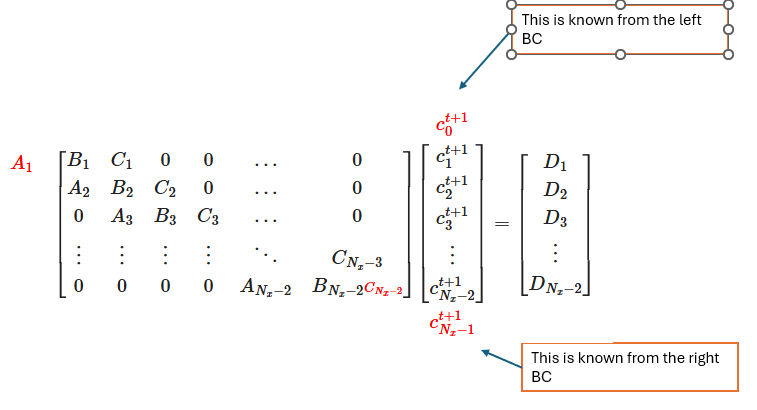

$$
\begin{array}{cc}
\begin{matrix} \color{red}{A_1} \\ \phantom{A_2} \\ \phantom{0} \\ \phantom{\vdots} \\ \phantom{0} \end{matrix}
&
\begin{bmatrix}
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} \color{red}{\scriptstyle C_{N_x-2}}
\end{bmatrix}
\begin{matrix}
\color{red}{c_0^{t+1}} \\
\begin{bmatrix}
c_1^{t+1} \\
c_2^{t+1} \\
c_3^{t+1} \\
\vdots \\
c_{N_x-2}^{t+1}
\end{bmatrix} \\
\color{red}{c_{N_x-1}^{t+1}}
\end{matrix}
=
\begin{bmatrix}
D_1 \\
D_2 \\
D_3 \\
\vdots \\
D_{N_x-2}
\end{bmatrix}
\end{array}
$$

If we move the known BCs in the constant D, this can be simplified to:
$$\begin{bmatrix} 
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} 
\end{bmatrix}
\begin{bmatrix} 
c_1^{t+1} \\
c_2^{t+1} \\
c_3^{t+1} \\
\vdots \\
c_{N_x-2}^{t+1}
\end{bmatrix}
=
\begin{bmatrix} 
D_1 \\
D_2 \\
D_3 \\
\vdots \\
D_{N_x-2}
\end{bmatrix}$$

### Implicit solution using Thomas Algorithm (Tridiagonal Matrix Algorithm): Will not be covered in this course

## Implicit solution using Iterative methods:
### Jacobi method

The Matrix of system of equations $ax = b$ for the unknown interior nodes looks like this: 

$$\begin{bmatrix} 
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} 
\end{bmatrix}
\begin{bmatrix} 
c_1^{t+1} \\
c_2^{t+1} \\
c_3^{t+1} \\
\vdots \\
c_{N_x-2}^{t+1}
\end{bmatrix}
=
\begin{bmatrix} 
D_1 \\
D_2 \\
D_3 \\
\vdots \\
D_{N_x-2}
\end{bmatrix}$$

$$ax = b$$
Decompose $a$ as $d + l + u$, where the terms are diagonal, lower and upper triangular:
$$(d + l + u)x = b$$

Move the non-diagonal terms ($l$ and $u$) to the right side:
$$dx = b - (l + u)x$$

To solve for $x$, multiply both sides by the inverse of the diagonal matrix $d^{-1}$:$$x = d^{-1} [b - (l + u)x]$$
In above, both sides are unknowns. If RHS was known through guess (or previous iteration), we could find the LHS. 

In the Jacobi method, we use the value from the current iteration ($k$) to find the next value ($k+1$). 
The matrix iteration equation is:$$x^{(k+1)} = d^{-1}b - d^{-1}(l + u)x^{(k)}$$

## Jacobi solution applied to 1D $c$ diffusion equation
For $k^{th}$ iteration,

$$x^{(k+1)} = d^{-1}b - d^{-1}(l + u)x^{(k)}$$

**BECOMES**

The i'th row of the diffusion equation looked like: 
$$
\begin{bmatrix} 
\dots & 0 & 0 & A_i & B_i & C_i & 0 & 0 & \dots 
\end{bmatrix}
\begin{bmatrix}
\vdots \\
c_{i-3}^{t+1} \\
c_{i-2}^{t+1} \\
c_{i-1}^{t+1} \\
c_i^{t+1} \\
c_{i+1}^{t+1} \\
c_{i+2}^{t+1} \\
c_{i+3}^{t+1} \\
\vdots
\end{bmatrix}
=
\begin{bmatrix}
\vdots \\
D_{i-2} \\
D_{i-1} \\
D_i \\
D_{i+1} \\
D_{i+2} \\
\vdots
\end{bmatrix}
$$

$d$: Diagonal matrix containing $B_i$. 

$l$: Lower triangular matrix containing $A_i$. 

$u$: Upper triangular matrix containing $C_i$.

Consider i'th row in the matrix

$$ c_{i(new)}^{k+1} = \frac{D_i - A_{i}c_{i-1}^k - C_{i}c_{i+1}^k}{B_i} $$ 

At end of each iteration,
$$c_i = c_{i(new)}$$

#### Memory required to store 2 arrays: $c_i$ and $c_{i(new)}$

In [12]:
c_jac = np.zeros(N_x)
A = np.zeros(N_x)
B = np.zeros(N_x)
C = np.zeros(N_x)
D = np.zeros(N_x)

c_jac[N_x//2] = 1.0 # initialization
apply_BC(c_jac)
c_jac_new = np.copy(c_jac)
alpha = Diffusivity*dt/(dx**2)
total_iterations = 10 # total number of iterations
for t in range(timesteps):
    A[1:N_x-1] = -alpha
    B[1:N_x-1] = (1 + 2*alpha)
    C[1:N_x-1] = -alpha
    D[1:N_x-1] = c_jac[1:N_x-1]
    
    for iterations in range(total_iterations):
        for i in range(1, N_x-1):
            c_jac_new[i] = (D[i] - A[i]*c_jac[i-1] - C[i]*c_jac[i+1])/B[i]
        apply_BC(c_jac_new)
        # update c_jac each iteration
        c_jac = np.copy(c_jac_new)

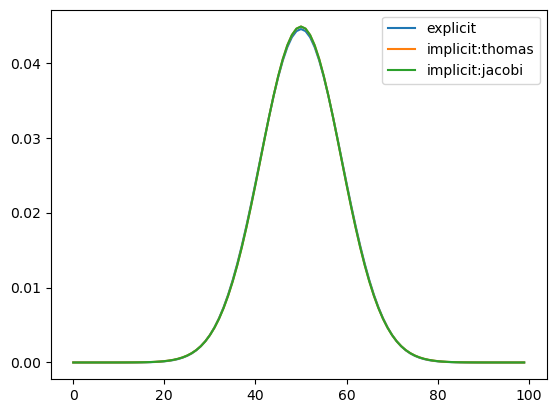

In [13]:
plt.plot(x_array, c_exp, label='explicit')
plt.plot(x_array, c_jac, label='implicit:jacobi')
plt.legend()

### Implicit solution using Iterative methods:
#### Gauss Seidel

$$Ax = b$$
Decompose
$$(D + L + U)x = b$$

Split this up, ($U$) to the right side:
$$(D+L)x = b - Ux$$

For $k^{th}$ iteration,
$$(D+L)x^{k+1} = b - Ux^k$$

$$Dx^{k+1} = b - Lx^{k+1} - Ux^k$$

For $k^{th}$ iteration and $i^{th}$ row in our 1D diffusion case, it becomes

$$ c_i^{k+1} = \frac{D_i - A_{i}c_{i-1}^{k+1} - C_{i}c_{i+1}^k}{B_i} $$ 

i.e. we are using the updated values of $c_{i-1}^{k+1}$ for $L$

Here, no need to save a new array, unlike Jacobi method. Update values for $(k+1)^{th}$ iteration in place. 

Gauss Seidel Matrix at $(k+1)^{th}$ iteration and t timestep at $i == 3$

$$\begin{bmatrix} 
B_1 & C_1 & 0 & 0 & \dots & 0 \\
A_2 & B_2 & C_2 & 0 & \dots & 0 \\
0 & A_3 & B_3 & C_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & C_{N_x-3} \\
0 & 0 & 0 & 0 & A_{N_x-2} & B_{N_x-2} 
\end{bmatrix}
\begin{bmatrix} 
\color{red}{c_1^{t+1, k+1}} \\
\color{red}{c_2^{t+1, k+1}} \\
c_3^{t+1, k} \\
\vdots \\
c_{N_x-2}^{t+1, k}
\end{bmatrix}
=
\begin{bmatrix} 
D_1 \\
D_2 \\
D_3 \\
\vdots \\
D_{N_x-2}
\end{bmatrix}$$

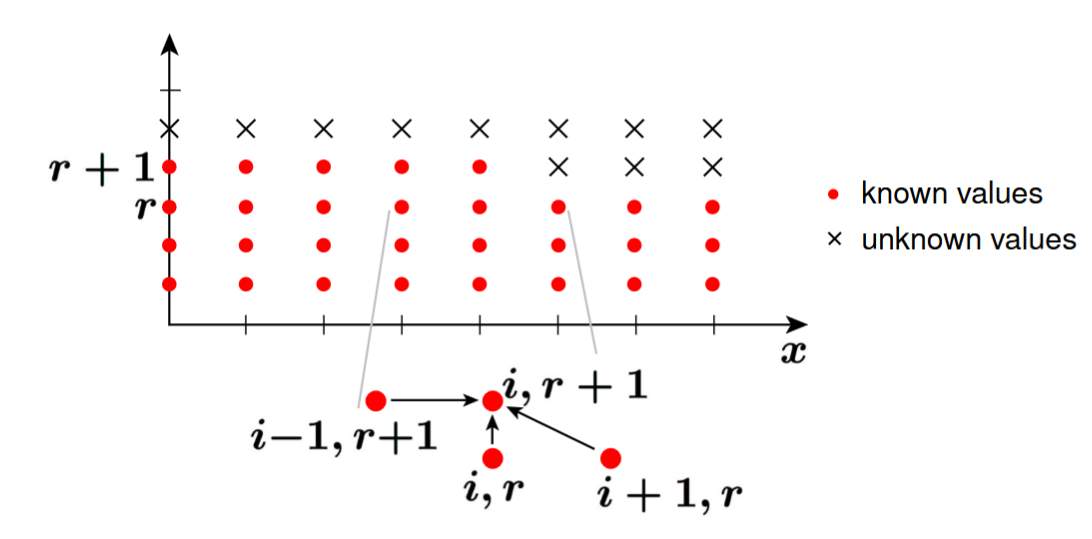

### Advantage of GS over Jacobi: Converges at half the no. of iterations.

#### Which of Jacobi or Gauss Seidel is parallelizable?

Gauss Seidel as discretized above is not parallelizable

How to make GS parallelizable?

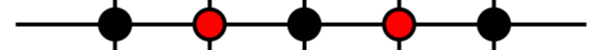

#### Red Black Gauss Seidel

For $ i == even$ (Red points), their update only depends upon Black points

$$ \color{red}{c_i^{k+1}} = \frac{D_i - A_{i}c_{i-1}^k - C_{i}c_{i+1}^k}{B_i} $$ 

Update all the (Red points) and then use these updated red points to update the Black points:

For $ i == odd$ (Black points),

$$ c_i^{k+1} = \frac{D_i - A_{i}\color{red}{c_{i-1}^{k+1}} - C_{i}\color{red}{c_{i+1}^{k+1}}}{B_i} $$ 

In [ ]:
c_rb = np.zeros(N_x)
A = np.zeros(N_x)
B = np.zeros(N_x)
C = np.zeros(N_x)
D = np.zeros(N_x)

c_rb[N_x//2] = 1.0 # initialization
apply_BC(c_rb)
alpha = Diffusivity*dt/(dx**2)
total_iterations = 10 # total number of iterations
for t in range(timesteps):
    A[1:N_x-1] = -alpha
    B[1:N_x-1] = (1 + 2*alpha)
    C[1:N_x-1] = -alpha
    D[1:N_x-1] = c_rb[1:N_x-1]
    
    for iterations in range(total_iterations):
        for i in range(1, N_x-1):
#             even points
            if i%2 == 0:
                c_rb[i] = (D[i] - A[i]*c_rb[i-1] - C[i]*c_rb[i+1])/B[i]
        apply_BC(c_rb)
        for i in range(1, N_x-1):
#             odd points
            if i%2 != 0:
                c_rb[i] = (D[i] - A[i]*c_rb[i-1] - C[i]*c_rb[i+1])/B[i]
        apply_BC(c_rb)

In [ ]:
# %matplotlib notebook
plt.plot(x_array, c_exp, label='explicit')
plt.plot(x_array, c_jac, label='implicit:jacobi')
plt.plot(x_array, c_rb, label='implicit:RB gauss-seidel')
# plt.ylim((-0.1, 0.2))
plt.legend()
plt.show()

## 2D Discretization and mesh structure
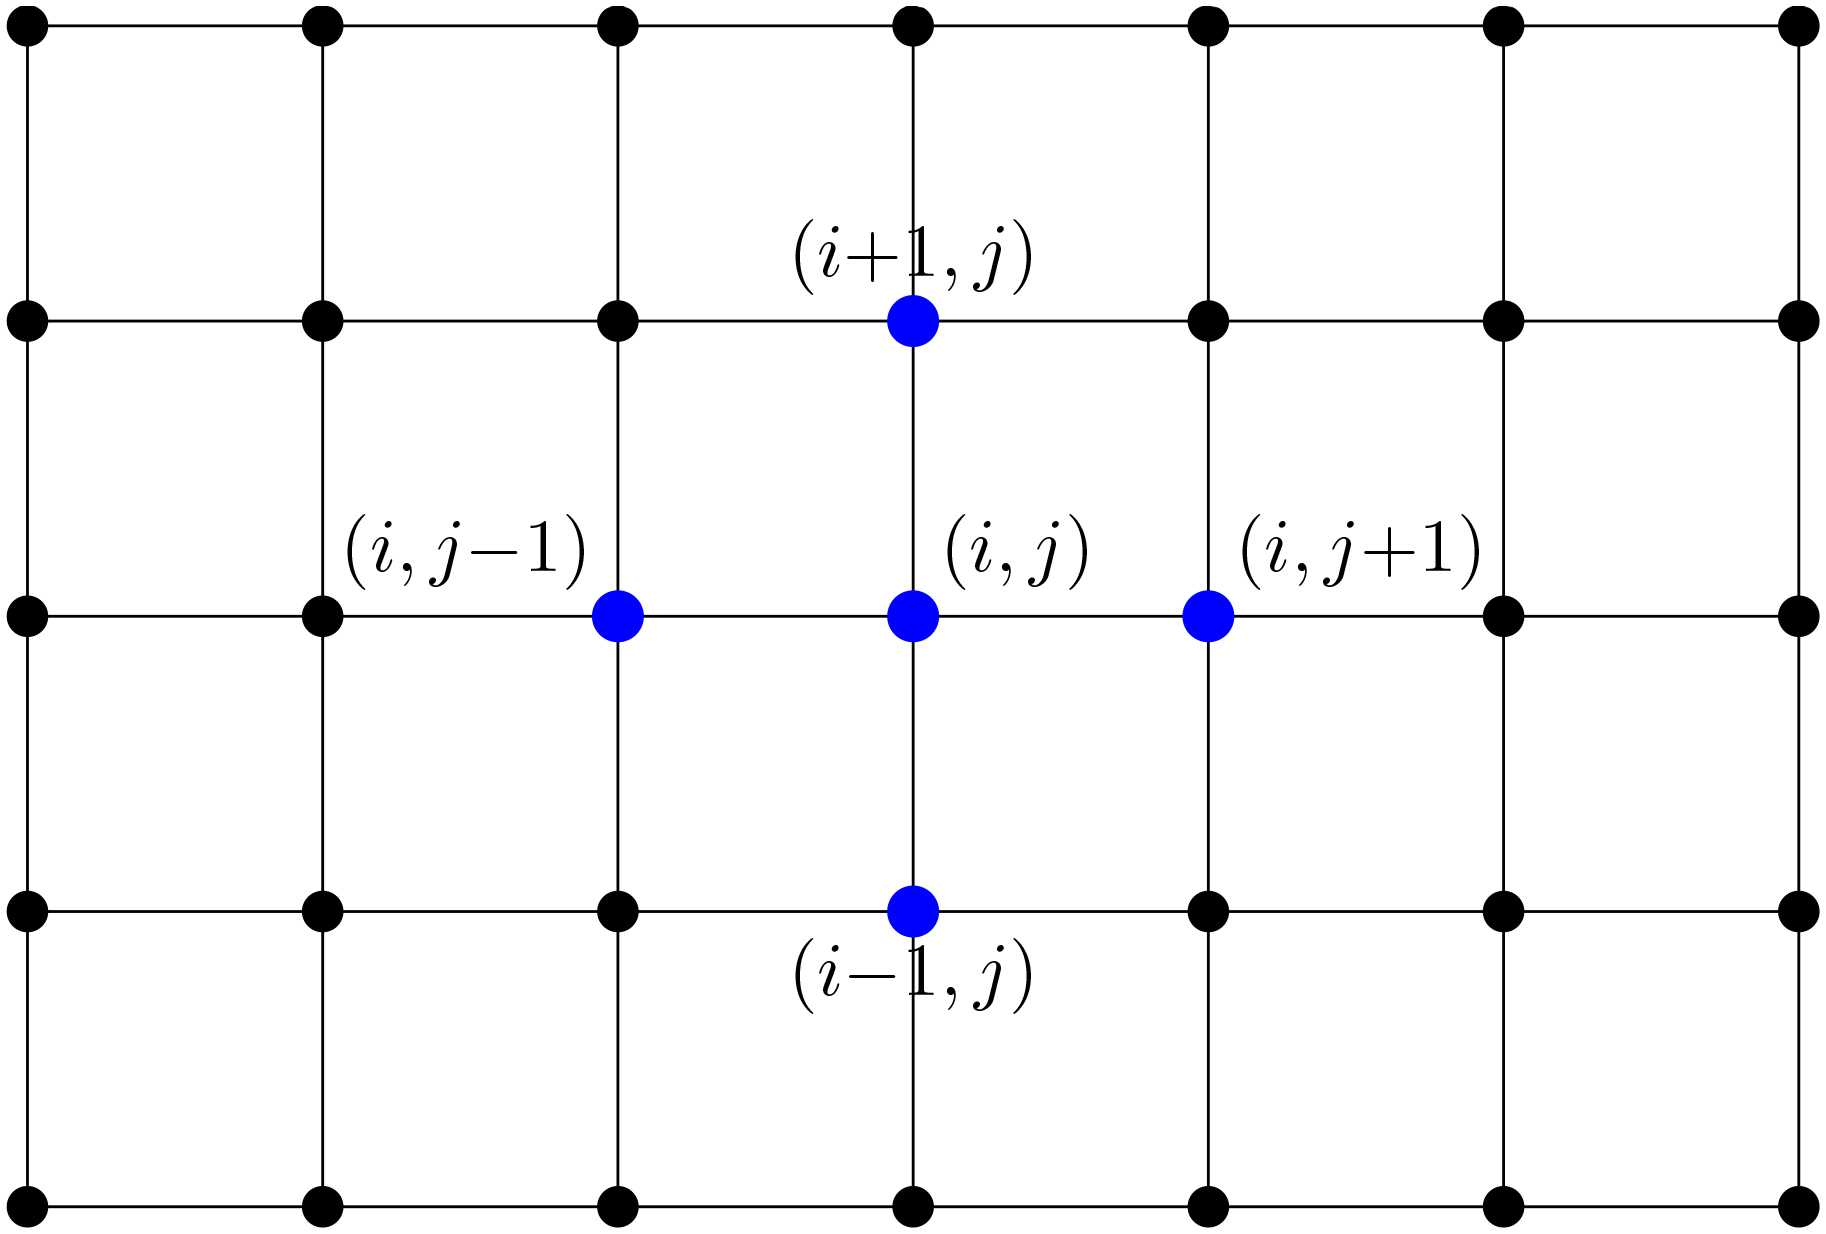

## 2D diffusion equation

$$\frac{\partial c}{\partial t} = D \left( \frac{\partial^2 c}{\partial x^2} + \frac{\partial^2 c}{\partial y^2} \right)$$

At point $(i, j)$ :

x-direction: $\frac{\partial^2 c}{\partial x^2} \approx \frac{c_{i+1, j} - 2c_{i,j} + c_{i-1, j}}{\Delta x^2}$y-direction: $\frac{\partial^2 c}{\partial y^2} \approx \frac{c_{i, j+1} - 2c_{i,j} + c_{i, j-1}}{\Delta y^2}$

### Explicit method

$$\frac{c_{i,j}^{t+1} - c_{i,j}^t}{\Delta t} = D \left[ \frac{c_{i+1,j}^{t} - 2c_{i,j}^{t} + c_{i-1,j}^{t}}{\Delta x^2} + \frac{c_{i,j+1}^{t} - 2c_{i,j}^{t} + c_{i,j-1}^{t}}{\Delta y^2} \right]$$

Make grid symmetric, i.e. $\Delta x$ = $\Delta y$ 

$$c_{i,j}^{t+1} = c_{i,j}^t + \alpha \left( c_{i+1,j}^t + c_{i-1,j}^t + c_{i,j+1}^t + c_{i,j-1}^t - 4c_{i,j}^t \right)$$


### Implicit method
$t+1$:
$$\frac{c_{i,j}^{t+1} - c_{i,j}^t}{\Delta t} = D \left[ \frac{c_{i+1,j}^{t+1} - 2c_{i,j}^{t+1} + c_{i-1,j}^{t+1}}{\Delta x^2} + \frac{c_{i,j+1}^{t+1} - 2c_{i,j}^{t+1} + c_{i,j-1}^{t+1}}{\Delta y^2} \right]$$

Make grid symmetric, i.e. $\Delta x$ = $\Delta y$ 

$$ -\alpha c_{i-1, j}^{t+1} -\alpha c_{i, j-1}^{t+1} + (1 + 4\alpha )c_{i, j}^{t+1} -\alpha c_{i+1, j}^{t+1} -\alpha c_{i, j+1}^{t+1} = c_{i, j}^t $$,

In simpler terms,
$$ A_{xi} c_{i-1, j}^{t+1} + A_{yi} c_{i, j-1}^{t+1} + B_{i, j} c_{i, j}^{t+1} + C_{xi} c_{i+1, j}^{t+1} + C_{yi} c_{i, j+1}^{t+1} = D_{i, j} $$

Stability Constraint:

Unlike the 1D case where $\alpha \le 0.5$, the 2D explicit method is more restrictive. For stability, it must satisfy:$$\alpha \le 0.25 \quad \text{or} \quad \Delta t \le \frac{\Delta x^2}{4D}$$

### Solving 2D diffusion equations

Iterative methods
* Jacobi
* Gauss Seidel (Red Black)
* ~~Alternate Direction Implicit~~



Gauss Seidel (Red Black)

The asterisk ($*$) below denotes that we use the most recent value available.

$$c_{i,j}^{k+1} = \frac{c_{i,j}^t + \alpha (c_{i-1,j}^* + c_{i+1,j}^* + c_{i,j-1}^* + c_{i,j+1}^*)}{1 + 4\alpha}$$

In Red-Black, we ensure that the "neighbors" are always from the opposite set.

A grid point is Red if $(i + j)\%2 == 0$ is even, and Black if $(i + j) \%2 \neq 0 $ is odd.

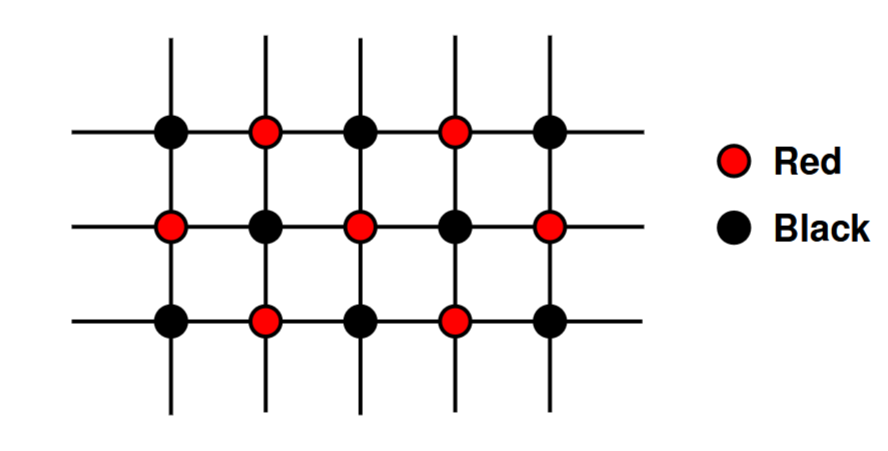

#### Step 1: Update Red Cells

Update all $(i, j)$ where $(i + j) \% 2 == 0$. Since all neighbors of a Red cell are Black, this step uses the values from the previous iteration ($k$):$$c_{Red}^{k+1} = f(c_{Black}^{k})$$

#### Step 2: Update Black Cells

Update all $(i, j)$ where $(i + j) \% 2 != 0$. Since all neighbors of a Black cell are Red, and those Red cells were just updated in Step 1, this step uses the new values ($k+1$):$$c_{Black}^{k+1} = f(c_{Red}^{k+1})$$

### Methods not covered
1. Alternate Direction Implicit (ADI)
2. Successive Over Relaxation (SOR)
3. Multigrid methods

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm # for choosing colormap for 3D plot

In [17]:
N_x, N_y = 50, 50
timesteps = 50
dx = 1.0 #  dx = dy
dt = 0.4
Diffusivity = 1.0

In [18]:
def initialize(c):
    c[N_x//2, N_y//2] = 1.0
    return
def apply_BC(c):
#    # Dirichlet (fixed) boundary condition
#     c[0, :] = 0.0
#     c[N_x-1, :] = 0.0
#     c[:, 0] = 0.0
#     c[:, N_y-1] = 0.0
#    # Neumann (zero-flux) boundary condition
    c[0, :] = c[1, :]
    c[N_x-1, :] = c[N_x-2, :]
    c[:, 0] = c[:, 1]
    c[:, N_y-1] = c[:, N_y-2]
    return

In [19]:
# Initializing parameters
alpha = Diffusivity*dt/(dx**2)
c_jac = np.zeros( (N_x, N_y) )
A_x = np.zeros( (N_x, N_y) )
A_y = np.zeros( (N_x, N_y) )
C_x = np.zeros( (N_x, N_y) )
C_y = np.zeros( (N_x, N_y) )
B = np.zeros( (N_x, N_y) )
D = np.zeros( (N_x, N_y) )
total_iterations = 10
initialize(c_jac)
apply_BC(c_jac)
c_jac_new = np.copy(c_jac)

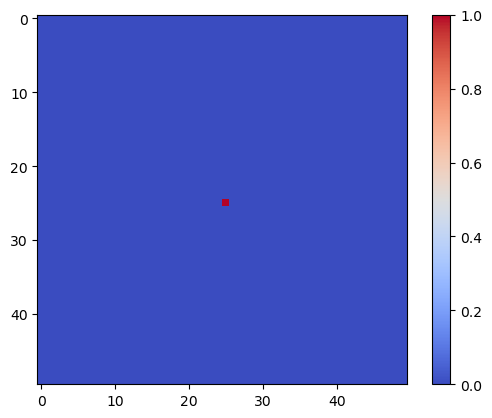

In [20]:
plt.imshow(c_jac, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

In [21]:
for t in range(timesteps):
    # update coefficients after each timestep
    A_x[1:N_x-1, 1:N_y-1] = -alpha
    A_y[1:N_x-1, 1:N_y-1] = -alpha
    C_x[1:N_x-1, 1:N_y-1] = -alpha
    C_y[1:N_x-1, 1:N_y-1] = -alpha
    B[1:N_x-1, 1:N_y-1] = 1+4*alpha
    D[1:N_x-1, 1:N_y-1] = c_jac[1:N_x-1, 1:N_y-1]
    
    for iterations in range(total_iterations*2):
#         for i in range(1, N_x-1):
#             for j in range(1, N_y-1):
#                     c_jac_new[i,j] = (D[i,j] - A_x[i,j]*c_jac[i-1,j] - C_x[i,j]*c_jac[i+1,j] \
#                                  - A_y[i,j]*c_jac[i,j-1] - C_y[i,j]*c_jac[i,j+1])/B[i,j]
        # vectorized form
        c_jac_new[1:-1, 1:-1] = (
                    D[1:-1, 1:-1] - 
                    A_x[1:-1, 1:-1] * c_jac[0:-2, 1:-1] - 
                    C_x[1:-1, 1:-1] * c_jac[2:  , 1:-1] - 
                    A_y[1:-1, 1:-1] * c_jac[1:-1, 0:-2] - 
                    C_y[1:-1, 1:-1] * c_jac[1:-1, 2:  ]
                ) / B[1:-1, 1:-1]
                    
                    
        # update c_jac each iteration
        apply_BC(c_jac_new)
        c_jac = np.copy(c_jac_new)

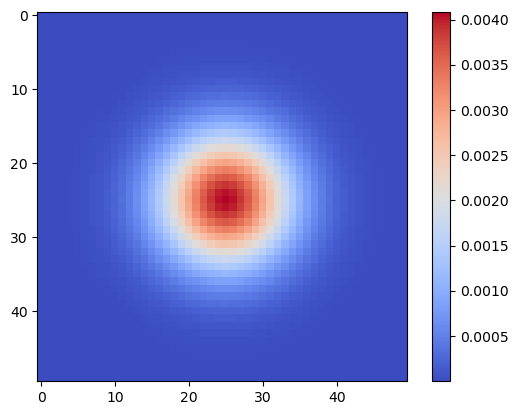

In [22]:
plt.imshow(c_jac, cmap=cm.coolwarm) # for plotting 2D projection with color as 3rd dimension
plt.colorbar()
plt.show()

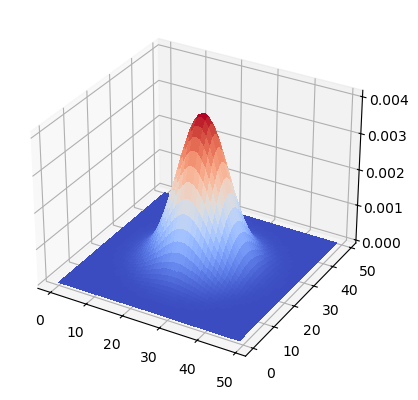

In [23]:
# %matplotlib notebook
%matplotlib inline
# 3D surface plot  
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(2) # creates a different window
ax = fig.add_subplot(111, projection='3d') # adds a third axis
x_array = np.arange(0, N_x, dx)
y_array = np.arange(0, N_y, dx)
X, Y = np.meshgrid(y_array, x_array) # creates an xy grid of size N_x*N_y
surf = ax.plot_surface(X, Y, c_jac, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
# fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()